In [1]:
# from evaluation.confusion_matrix_visualization import plot_confusion_matrix_percentage
# import os
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
# res_dir = os.path.join('..', 'Res', 'PTGA_performance') 
res_dir = os.path.join('..', 'evaluation') 
# dataset_name = 'dataset_29_d1' 
# dataset_name = 'dataset_20_d2'
# dataset_name = 'ISCX-VPN' 
dataset_name = 'ISCX-TOR-Application'
# dataset_name = 'USTC-TFC2016-Malware'
# exp_name = '0.1s_flow' 
# exp_name = '0.01s'
# exp_name = '0.02s_ip' 
# exp_name = '0.5s_flow' 
# exp_name = '0.05s_ip'

tor_app_label_list = ['Youtube','Twitter','Spotify','Facebook','Vimeo','Google']

exp_name = '0.5s_flow'
exp_name_list = ['0.03s', '0.03s_flow', '0.1s', '0.1s_flow', '0.5s', '0.5s_flow']
train_log_postfix = '_train_set_training_log'
field_importance_postfix = '_train_set_feature_importance_report'
expert_importance_postfix = '_train_set_expert_layer_importance'
confusion_matrix_postfix = '_train_set_final_test_confusion_matrix' 

output_dir = os.path.join(res_dir, dataset_name, exp_name, 'matrix_visualization')
output_path = os.path.join(output_dir, exp_name + '.pdf')

train_log_path = os.path.join(res_dir, dataset_name, exp_name, dataset_name + train_log_postfix + '.csv')
field_importance_path = os.path.join(res_dir, dataset_name, exp_name, dataset_name + field_importance_postfix + '.csv')
expert_importance_path = os.path.join(res_dir, dataset_name, exp_name, dataset_name + expert_importance_postfix + '.csv') 
confusion_matrix_path = os.path.join(res_dir, dataset_name, exp_name, dataset_name + confusion_matrix_postfix + '.csv')
# yaml_path = os.path.join('.', 'Data', 'fields_embedding_configs_v1.yaml')

In [3]:
csv_paths = []
for e_name in exp_name_list: 
    csv_path = os.path.join(res_dir, dataset_name, e_name, dataset_name + confusion_matrix_postfix + '.csv')
    csv_paths.append(csv_path)

cm_list = [pd.read_csv(path, index_col=0) for path in csv_paths]

label_order = tor_app_label_list

cm_list = [
    cm.loc[label_order, label_order]
    for cm in cm_list
]

titles = [
    "3% sampling",
    "10% sampling",
    "50% sampling",
    "3% + Flow",
    "10% + Flow",
    "50% + Flow"
]

FileNotFoundError: [Errno 2] No such file or directory: '..\\evaluation\\ISCX-TOR-Application\\0.03s\\ISCX-TOR-Application_train_set_final_test_confusion_matrix.csv'

In [ ]:
def plot_confusion_matrix_percentage(
    csv_path: str,
    output_pdf_path: str,
    cmap: str = "Blues",
    figsize=(5.5, 4.8),
    tick_label_size: int = 14,
    annot_font_size: int = 14,
    show_colorbar: bool = True, 
    cbar_label_size: int = 14,
    cbar_outline: bool = False,
    cbar_outline_width: float = 0.8, 
    if_save: bool = False,
    label_order: list = None  # 新增参数
):
    """
    Plot a row-normalized confusion matrix (percentage-based heatmap).

    Parameters
    ----------
    csv_path : str
        Path to confusion matrix CSV file.
    output_pdf_path : str
        Output path for the PDF figure.
    cmap : str
        Colormap for heatmap.
    figsize : tuple
        Figure size.
    tick_label_size : int
        Font size for x/y tick labels.
    annot_font_size : int
        Font size for percentage annotations.
    show_colorbar : bool
        Whether to show the colorbar.
    if_save : bool
        Whether to save the figure.
    label_order : list, optional
        Custom order of labels. If provided, sorts both rows and columns by this order.
        If None (default), sorts by row sample count (descending).
    """

    sns.set(style="white")
    mpl.rcParams.update({
        "font.family": "Times New Roman",
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False
    })

    # 1. Load confusion matrix
    cm = pd.read_csv(csv_path, index_col=0)

    # 2. Sort labels
    if label_order is not None:
        # 验证所有指定的标签都存在于数据中
        missing_labels = set(label_order) - set(cm.index)
        if missing_labels:
            raise ValueError(f"Specified labels not found in CSV: {missing_labels}")
        
        # 保留原数据中有的标签，按照 label_order 的顺序排列
        available_labels = [label for label in label_order if label in cm.index]
        
        # 如果还有未在 label_order 中指定的标签，添加到末尾（或抛出警告）
        remaining_labels = [label for label in cm.index if label not in label_order]
        if remaining_labels:
            print(f"Warning: The following labels are not in label_order and will be appended: {remaining_labels}")
            available_labels.extend(remaining_labels)
        
        sorted_labels = available_labels
    else:
        # 默认：按行样本数降序排列
        row_sums = cm.sum(axis=1)
        sorted_labels = row_sums.sort_values(ascending=False).index

    # 确保列也按照相同的顺序排列（混淆矩阵应该是方阵）
    cm_sorted = cm.loc[sorted_labels, sorted_labels]

    # 3. Row-wise normalization (%)
    cm_percentage = cm_sorted.div(cm_sorted.sum(axis=1), axis=0) * 100

    # 4. Plot
    plt.figure(figsize=figsize)

    ax = sns.heatmap(
        cm_percentage,
        cmap=cmap,
        vmin=0,
        vmax=100,
        square=True,
        annot=True,
        fmt=".1f",
        annot_kws={"size": annot_font_size},
        linewidths=0.4,
        cbar=show_colorbar,
        # cbar_kws={"label": "Percentage (%)"} if show_colorbar else None
        cbar_kws={}
    )

        # --- Colorbar fine control ---
    if show_colorbar:
        cbar = ax.collections[0].colorbar

        # 1. Colorbar label font size
        cbar.set_label("Percentage (%)", fontsize=cbar_label_size)

        # 2. Tick label size
        cbar.ax.tick_params(labelsize=cbar_label_size - 1)

        # 3. Outline (border)
        if cbar_outline:
            cbar.outline.set_visible(True)
            cbar.outline.set_linewidth(cbar_outline_width)
            
        else:
            cbar.outline.set_visible(False)
            cbar.ax.tick_params(axis='y', length=0)

    # ax.set_title("")
    # ax.set_xlabel("Predicted label", fontsize=tick_label_size)
    # ax.set_ylabel("True label", fontsize=tick_label_size)
    # ax.tick_params(axis="x", labelsize=tick_label_size)
    # ax.tick_params(axis="y", labelsize=tick_label_size)

    # 1. Remove axis titles (redundant in multi-panel figures)
    # ax.set_xlabel("")
    # ax.set_ylabel("")
    ax.set_xlabel("Predicted label", fontsize=tick_label_size+1)
    ax.set_ylabel("True label", fontsize=tick_label_size+1)
    
    # 2. Tick label font size
    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    
    # 3. Rotate tick labels for better readability
    plt.setp(
        ax.get_xticklabels(),
        rotation=20,
        ha="center",
        rotation_mode="anchor"
    )
    
    plt.setp(
        ax.get_yticklabels(),
        rotation=0,
        ha="right"
    )

    # --- Add outer border ---
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_edgecolor("black")

    plt.tight_layout()
    
    if output_pdf_path:
        dir_name = os.path.dirname(output_pdf_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)
    
    if if_save:
        plt.savefig(output_pdf_path, format="pdf", bbox_inches='tight')
        print("PDF is saved.")
    
    plt.show()
    plt.close()

In [ ]:
def plot_percentage_colorbar_horizontal(
    output_pdf_path: str,
    cmap: str = "Blues",
    vmin: float = 0.0,
    vmax: float = 100.0,
    figsize=(12, 0.3),
    label: str = "Percentage (%)",
    label_font_size: int = 16,
    tick_font_size: int = 14, 
    if_save: bool = False
):
    """
    Plot a standalone horizontal colorbar for percentage-based heatmaps.
    """

    mpl.rcParams.update({
        "font.family": "Times New Roman",
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False
    })

    fig, ax = plt.subplots(figsize=figsize)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=ax, orientation="horizontal")
    cbar.set_label(label, fontsize=label_font_size)
    cbar.ax.tick_params(labelsize=tick_font_size)

    # 删除 colorbar 的边框（outline）
    cbar.outline.set_visible(False)

    # 可选：同时删除 tick 的刻度线（只保留数字标签，更简洁）
    cbar.ax.tick_params(axis='x', length=0)

    plt.tight_layout()
    os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)
    if if_save: 
        plt.savefig(output_pdf_path, format="pdf",  bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close()

In [ ]:
def plot_confusion_matrix_panel(
    cm_list,
    titles=None,
    normalize=True,
    cmap="Blues",
    vmin=0,
    vmax=100,
    figsize=(18, 4),
    font_family="Times New Roman",
    annot=True,
    annot_fontsize=10,
    tick_fontsize=10,
    title_fontsize=12,
    show_colorbar=True,
    colorbar_label="Percentage (%)",
    colorbar_labelsize=12,
    colorbar_ticksize=10,
    border_linewidth=1.0,
    only_left_yaxis=True,
    x_label="Experts",
    y_label="Layers",
):
    """
    Plot multiple confusion matrices in one row with shared colorbar.
    """

    # Global font
    mpl.rcParams.update({
        "font.family": font_family,
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False
    })

    num_matrices = len(cm_list)

    fig, axes = plt.subplots(
        1,
        num_matrices,
        figsize=figsize,
        sharey=True
    )

    if num_matrices == 1:
        axes = [axes]

    # Normalize if required
    processed_cms = []
    for cm in cm_list:
        if isinstance(cm, pd.DataFrame):
            data = cm.values
        else:
            data = np.array(cm)

        if normalize:
            row_sum = data.sum(axis=1, keepdims=True)
            row_sum[row_sum == 0] = 1
            data = data / row_sum * 100

        processed_cms.append(data)

    # Plot each heatmap
    for i, ax in enumerate(axes):
        sns.heatmap(
            processed_cms[i],
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            square=True,
            annot=annot,
            fmt=".1f" if normalize else "d",
            annot_kws={"size": annot_fontsize},
            cbar=False,
            linewidths=0.4
        )

        # Title
        if titles:
            ax.set_title(titles[i], fontsize=title_fontsize)

        # Axis labels
        ax.set_xlabel(x_label, fontsize=tick_fontsize)

        if i == 0 or not only_left_yaxis:
            ax.set_ylabel(y_label, fontsize=tick_fontsize)
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        # Tick label size & rotation
        ax.tick_params(axis="x", labelsize=tick_fontsize)
        ax.tick_params(axis="y", labelsize=tick_fontsize)

        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        plt.setp(ax.get_yticklabels(), rotation=0)

        # Outer border
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(border_linewidth)
            spine.set_edgecolor("black")

    # Shared colorbar
    if show_colorbar:
        cbar = fig.colorbar(
            mpl.cm.ScalarMappable(
                norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax),
                cmap=cmap
            ),
            ax=axes,
            fraction=0.02,
            pad=0.02
        )
        cbar.set_label(colorbar_label, fontsize=colorbar_labelsize)
        cbar.ax.tick_params(labelsize=colorbar_ticksize)
        cbar.outline.set_linewidth(0.8)

    plt.tight_layout()
    return fig

In [4]:
fig = plot_confusion_matrix_panel(
    cm_list=cm_list,
    titles=titles,
    cmap="Blues",
    figsize=(18, 4),
    annot=False,
    title_fontsize=13,
    tick_fontsize=11
)

plt.show()

NameError: name 'plot_confusion_matrix_panel' is not defined

C:\Users\PC\AppData\Local\Temp\ipykernel_33336\1325730900.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


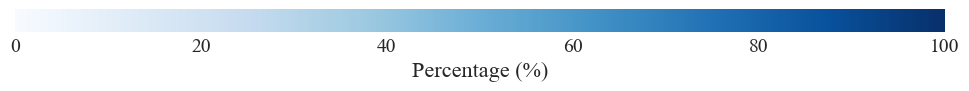

In [69]:
plot_percentage_colorbar_horizontal(output_pdf_path=os.path.join(res_dir, dataset_name, 'color_bar.pdf'), if_save=True)

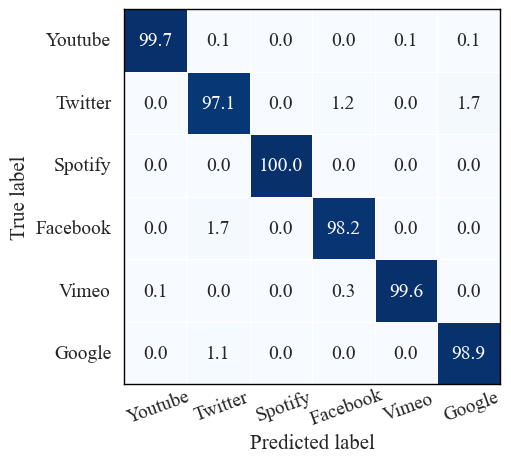

In [67]:
plot_confusion_matrix_percentage(csv_path=confusion_matrix_path, output_pdf_path=output_path,show_colorbar=False, if_save=False, label_order=tor_app_label_list)

PDF is saved.


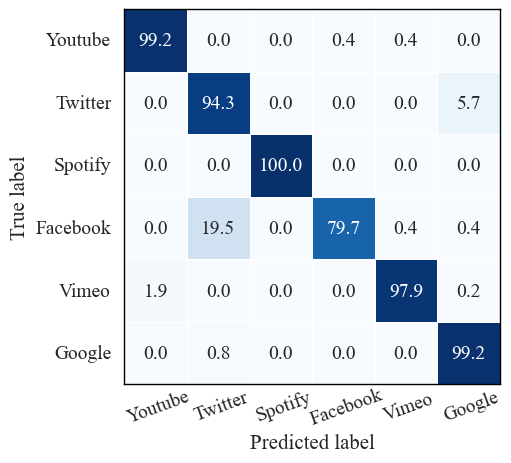

PDF is saved.


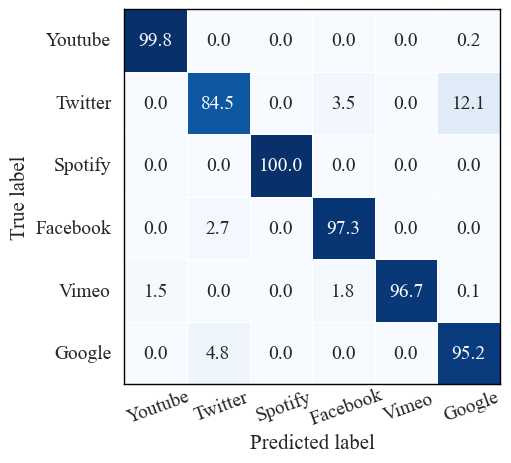

PDF is saved.


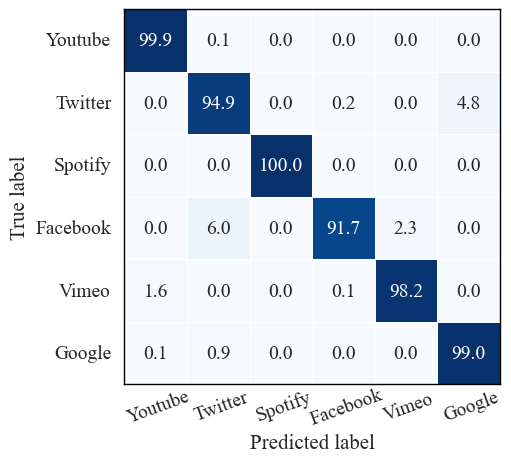

PDF is saved.


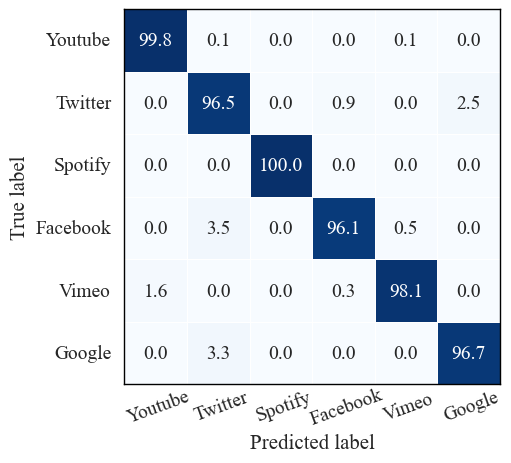

PDF is saved.


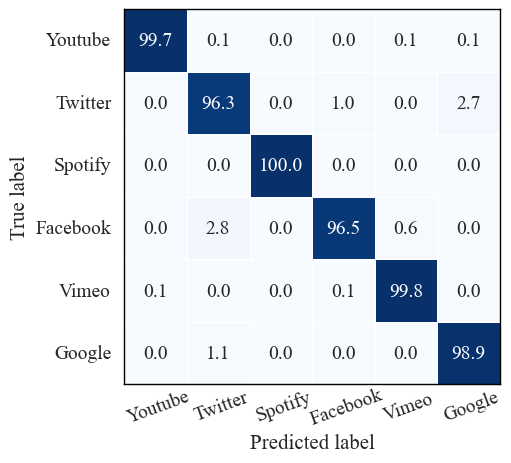

PDF is saved.


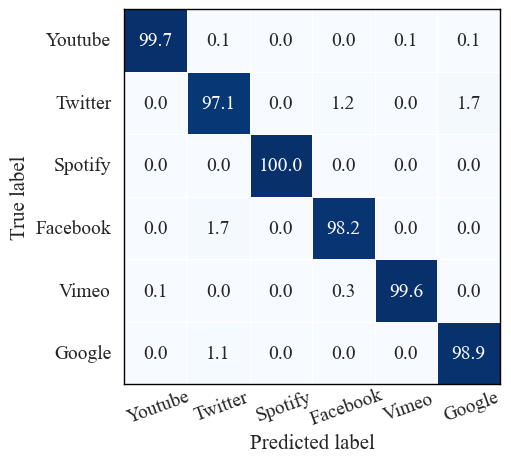

In [73]:
for e_name in exp_name_list: 
    in_path = os.path.join(res_dir, dataset_name, e_name, dataset_name + confusion_matrix_postfix + '.csv')
    out_dir = os.path.join(res_dir, dataset_name, 'matrix_visualization')
    out_path = os.path.join(out_dir, e_name + '.pdf')
    plot_confusion_matrix_percentage(csv_path=in_path, output_pdf_path=out_path,show_colorbar=False, if_save=True, label_order=tor_app_label_list)